In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1


# there are all the sessions
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }


In [4]:

# --- Extract task-anchoring labels and compute abundance for all GCS and NGS cells ---
all_gcs_dfs = []
all_ngs_dfs = []

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")

        try:
            gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  Failed to load Mouse {mouse} Day {day}: {e}")
            continue

        print(f'  {len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all)} total cells')

        for cell_type, cell_df in [('GCS', gcs), ('NGS', ngs)]:
            abundances = []
            for cluster_id in cell_df.cluster_id.values:
                try:
                    tc = tcs[cluster_id] if cluster_id in tcs else None
                    if tc is None:
                        abundances.append(np.nan)
                        continue
                    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                    tc = tc[:last_ephys_bin]
                    tcs_to_use = {cluster_id: tc, 1000: tc}

                    results = spectral_analysis(tcs_to_use, tl, bs=bs)
                    spectrograms = results[3]
                    S = spectrograms.mean(0)
                    max_peaks = np.argmax(S, axis=0)
                    labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                    labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)

                    n_total = len(labels)
                    n_anchored = int(np.sum(labels == 1))
                    abundances.append(n_anchored / n_total if n_total > 0 else np.nan)

                except Exception as e:
                    print(f"    Error processing {cell_type} cluster {cluster_id}: {e}")
                    abundances.append(np.nan)

            out = cell_df.copy()
            out['mouse'] = mouse
            out['day'] = day
            out['task_anchoring_abundance'] = abundances

            if cell_type == 'GCS':
                all_gcs_dfs.append(out)
            else:
                all_ngs_dfs.append(out)

all_gcs = pd.concat(all_gcs_dfs, ignore_index=True)
all_ngs = pd.concat(all_ngs_dfs, ignore_index=True)

print(f"\nDone. {len(all_gcs)} GCS cells, {len(all_ngs)} NGS cells.")
all_gcs.head()


Processing Mouse 20 Day 14...
  1 GCS cells, 101 NGS cells, 199 total cells
Processing Mouse 20 Day 15...
  1 GCS cells, 47 NGS cells, 65 total cells
Processing Mouse 20 Day 16...
  6 GCS cells, 154 NGS cells, 209 total cells
    Error processing NGS cluster 234: all input arrays must have the same shape
Processing Mouse 20 Day 17...
  2 GCS cells, 64 NGS cells, 107 total cells
Processing Mouse 20 Day 18...
  1 GCS cells, 92 NGS cells, 133 total cells
Processing Mouse 20 Day 19...
  0 GCS cells, 85 NGS cells, 108 total cells
    Error processing NGS cluster 186: all input arrays must have the same shape
    Error processing NGS cluster 401: all input arrays must have the same shape
Processing Mouse 20 Day 20...
  7 GCS cells, 76 NGS cells, 99 total cells
Processing Mouse 20 Day 21...
  1 GCS cells, 58 NGS cells, 107 total cells
Processing Mouse 20 Day 22...
  0 GCS cells, 60 NGS cells, 66 total cells
Processing Mouse 20 Day 23...
  0 GCS cells, 52 NGS cells, 74 total cells
Processing M

,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,null_grid_score,...,SC_x,SC_y,SC_z,probe_x,probe_y,theta_index,firing_rate,firing_rate_OF1,firing_rate_VR,task_anchoring_abundance
0,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,None,...,-3655.888528,3741.751806,4201.968554,750.0,615.0,0.029944,6.536149,6.936840,7.255499,0.267857
1,220,ENTm3,0.339731,47.923674,63.898232,20.602474,1.5,3,True,None,...,-3510.000000,3300.592848,4246.023178,500.0,1035.0,0.036023,1.817727,3.331167,0.689566,0.149254
2,152,ENTm1,0.529560,25.805901,34.407868,29.303829,1.5,12,True,"[-0.0886751427729628, -0.1132305951940929, 0.0...",...,-3330.000000,3987.051630,4240.477158,250.0,375.0,0.061667,1.420609,3.136529,0.854472,0.051020
3,252,ENTm2,0.554809,47.255555,63.007406,1.410203,1.5,12,True,None,...,-3510.000000,4151.534849,4162.820346,532.0,180.0,0.041887,9.383997,7.364530,10.899350,0.229592
4,258,ENTm2,0.174685,33.450813,44.601084,0.169808,1.5,12,False,None,...,-3510.000000,4076.890814,4170.118840,500.0,255.0,0.079080,11.643582,9.857306,13.145721,0.119898


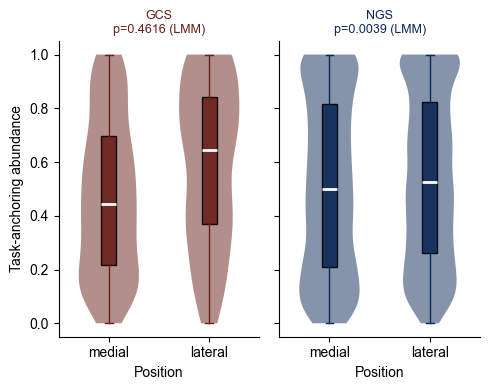

In [ ]:

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

all_gcs['SC_x'] = np.abs(all_gcs['SC_x'])
all_ngs['SC_x'] = np.abs(all_ngs['SC_x'])
all_gcs['medial_lateral'] = np.where(all_gcs['SC_x'] < 3400, 'medial', 'lateral')
all_ngs['medial_lateral'] = np.where(all_ngs['SC_x'] < 3400, 'medial', 'lateral')

all_gcs['cell_type'] = 'GCS'
all_ngs['cell_type'] = 'NGS'
plot_df = pd.concat([all_gcs, all_ngs], ignore_index=True).dropna(
    subset=['task_anchoring_abundance', 'medial_lateral', 'mouse', 'day']
)
plot_df['mouse_day'] = plot_df['mouse'].astype(str) + '_' + plot_df['day'].astype(str)
plot_df['position_code'] = (plot_df['medial_lateral'] == 'lateral').astype(float)

cell_types = ['GCS', 'NGS']
positions  = ['medial', 'lateral']
colors     = {'GCS': '#69201a', 'NGS': '#0d2958'}

fig, axes = plt.subplots(1, 2, figsize=(5, 4), sharey=True)

for ax, cell_type in zip(axes, cell_types):
    ct_df = plot_df[plot_df['cell_type'] == cell_type].copy()
    color = colors[cell_type]

    group_vals = []
    group_means = []
    for x_pos, position in enumerate(positions):
        vals = ct_df[ct_df['medial_lateral'] == position]['task_anchoring_abundance'].dropna().values
        group_vals.append(vals)
        group_means.append(np.mean(vals))

        # Violin
        parts = ax.violinplot(vals, positions=[x_pos], widths=0.6,
                              showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.5)

        # Box plot overlaid
        ax.boxplot(
            vals, positions=[x_pos], widths=0.15,
            patch_artist=True, showfliers=False,
            medianprops=dict(color='white', linewidth=2),
            boxprops=dict(facecolor=color, alpha=0.9),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
        )

        # Mean marker
        ax.scatter([x_pos], [group_means[-1]], color='white', s=30, zorder=5, marker='D',
                   edgecolors=color, linewidths=1)

    # Difference of means annotation
    diff = group_means[1] - group_means[0]  # lateral - medial
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else max(np.concatenate(group_vals))
    bracket_y = y_top * 1.05
    ax.annotate('', xy=(1, bracket_y), xytext=(0, bracket_y),
                arrowprops=dict(arrowstyle='-', color='black', lw=1))
    ax.text(0.5, bracket_y * 1.02, f'Δ={diff:+.3f}', ha='center', va='bottom',
            fontsize=8, color='black')

    # Linear mixed model
    try:
        lmm = smf.mixedlm(
            "task_anchoring_abundance ~ position_code",
            data=ct_df,
            groups=ct_df["mouse"],
            vc_formula={"day": "0 + C(day)", "cluster": "0 + C(cluster_id)"},
        )
        res = lmm.fit(reml=False, method='lbfgs')
        p = res.pvalues['position_code']
        ax.set_title(f'{cell_type}\np={p:.4f} (LMM)', fontsize=9, color=color)
    except Exception as e:
        ax.set_title(f'{cell_type}\nLMM error', fontsize=9, color=color)
        print(f'{cell_type} LMM error: {e}')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(positions)
    ax.set_xlabel('Position')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel('Task-anchoring abundance')
plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/task_anchoring_abundance_medial_lateral.pdf'
)
plt.show()
